# 03 - Evaluación de Métricas del Modelo

Evaluamos el rendimiento del modelo entrenado usando métricas estándar de clasificación.

## ¿Qué métricas calcularemos?
- **Accuracy**: Porcentaje general de predicciones correctas
- **Precision**: De todas las predicciones de una clase, ¿cuántas fueron correctas?
- **Recall**: De todos los ejemplos reales de una clase, ¿cuántos identificó el modelo?
- **F1-Score**: Media armónica de precision y recall (balance entre ambas)
- **Matriz de Confusión**: Visualización de errores entre clases

## 1. Importar librerías

Usamos sklearn para calcular métricas y seaborn/matplotlib para visualizaciones.

In [1]:
import spacy
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Cargar el modelo entrenado

Cargamos el modelo guardado en la carpeta `models/intent_classifier/`.

In [2]:
# Cargar modelo entrenado
model_path = Path("../models/intent_classifier")
nlp = spacy.load(model_path)

# Obtener las etiquetas del modelo
all_labels = list(nlp.get_pipe("textcat_multilabel").labels)

print(f"✅ Modelo cargado desde: {model_path}")
print(f"📋 Pipeline: {nlp.pipe_names}")
print(f"🏷️ Etiquetas ({len(all_labels)}): {sorted(all_labels)}")

✅ Modelo cargado desde: ..\models\intent_classifier
📋 Pipeline: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'textcat_multilabel']
🏷️ Etiquetas (22): ['agradecimiento', 'app_movil', 'cancelar_pedido', 'confirmar_pedido', 'consultar_horario', 'consultar_menu', 'consultar_precio', 'consultar_ubicacion', 'delivery', 'despedida', 'fallback', 'hablar_humano', 'info_empresa', 'metodos_pago', 'modificar_pedido', 'opinion_comida', 'queja', 'realizar_pedido', 'reservacion', 'retiro_local', 'saludo', 'trabajo']


## 3. Cargar datos de evaluación

Usamos los mismos datos de `intents.jsonl` y recreamos la división train/test con la misma semilla para obtener el mismo conjunto de validación.

In [3]:
# Cargar datos
data = []
with open('../data/intents.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

# Extraer textos y etiquetas
texts = [item['text'] for item in data]
labels = [item['label'] for item in data]

# Dividir con la misma semilla que en entrenamiento
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"📊 Datos cargados:")
print(f"   Total: {len(data)} ejemplos")
print(f"   Validación: {len(val_texts)} ejemplos")
print(f"   Intents únicos: {len(set(labels))}")

📊 Datos cargados:
   Total: 479 ejemplos
   Validación: 96 ejemplos
   Intents únicos: 22


## 4. Generar predicciones

Pasamos todos los textos de validación por el modelo y obtenemos las predicciones.

In [4]:
# Generar predicciones para el conjunto de validación
y_true = val_labels  # Etiquetas reales
y_pred = []          # Predicciones del modelo
y_conf = []          # Confianza de cada predicción

for text in val_texts:
    doc = nlp(text)
    # Obtener la categoría con mayor probabilidad
    predicted = max(doc.cats, key=doc.cats.get)
    confidence = doc.cats[predicted]
    y_pred.append(predicted)
    y_conf.append(confidence)

print(f"✅ Predicciones generadas: {len(y_pred)}")
print(f"📊 Confianza promedio: {np.mean(y_conf):.2%}")
print(f"📊 Confianza mínima: {np.min(y_conf):.2%}")
print(f"📊 Confianza máxima: {np.max(y_conf):.2%}")

✅ Predicciones generadas: 96
📊 Confianza promedio: 68.59%
📊 Confianza mínima: 0.12%
📊 Confianza máxima: 99.99%


## 5. Métricas Generales

Calculamos las métricas globales del modelo:
- **Accuracy**: % de predicciones correctas del total
- **Precision (macro)**: Promedio de precision por clase
- **Recall (macro)**: Promedio de recall por clase  
- **F1-Score (macro)**: Promedio de F1 por clase

In [5]:
# Calcular métricas generales
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("=" * 50)
print("📊 MÉTRICAS GENERALES DEL MODELO")
print("=" * 50)
print(f"\n   Accuracy:  {accuracy:.2%}")
print(f"   Precision: {precision:.2%}")
print(f"   Recall:    {recall:.2%}")
print(f"   F1-Score:  {f1:.2%}")
print("=" * 50)

# Interpretación
if accuracy >= 0.90:
    print("\n✅ Excelente rendimiento (>90%)")
elif accuracy >= 0.80:
    print("\n✅ Buen rendimiento (80-90%)")
elif accuracy >= 0.70:
    print("\n⚠️ Rendimiento aceptable (70-80%)")
else:
    print("\n❌ Rendimiento bajo (<70%) - se recomienda más datos")

📊 MÉTRICAS GENERALES DEL MODELO

   Accuracy:  60.42%
   Precision: 51.89%
   Recall:    54.66%
   F1-Score:  51.12%

❌ Rendimiento bajo (<70%) - se recomienda más datos


## 6. Reporte de Clasificación por Intent

Mostramos precision, recall y F1 para **cada intent** individualmente.
Esto ayuda a identificar qué clases tienen problemas.

In [6]:
# Reporte de clasificación detallado
print("📋 REPORTE DE CLASIFICACIÓN POR INTENT")
print("=" * 70)
print(classification_report(y_true, y_pred, zero_division=0))

📋 REPORTE DE CLASIFICACIÓN POR INTENT
                     precision    recall  f1-score   support

     agradecimiento       1.00      0.60      0.75         5
          app_movil       0.00      0.00      0.00         2
    cancelar_pedido       0.50      0.75      0.60         4
   confirmar_pedido       0.67      0.50      0.57         4
  consultar_horario       0.75      0.60      0.67         5
     consultar_menu       0.50      0.70      0.58        10
   consultar_precio       0.89      1.00      0.94         8
consultar_ubicacion       0.57      0.80      0.67         5
           delivery       0.40      0.50      0.44         4
          despedida       1.00      0.50      0.67         4
           fallback       0.33      0.14      0.20         7
      hablar_humano       0.25      0.33      0.29         3
       info_empresa       0.00      0.00      0.00         2
       metodos_pago       0.40      0.67      0.50         3
   modificar_pedido       0.57      1.00      

## 7. Visualización de Métricas por Intent

Un gráfico de barras que muestra F1-Score de cada intent.
Las barras rojas indican intents con bajo rendimiento (F1 < 0.7).

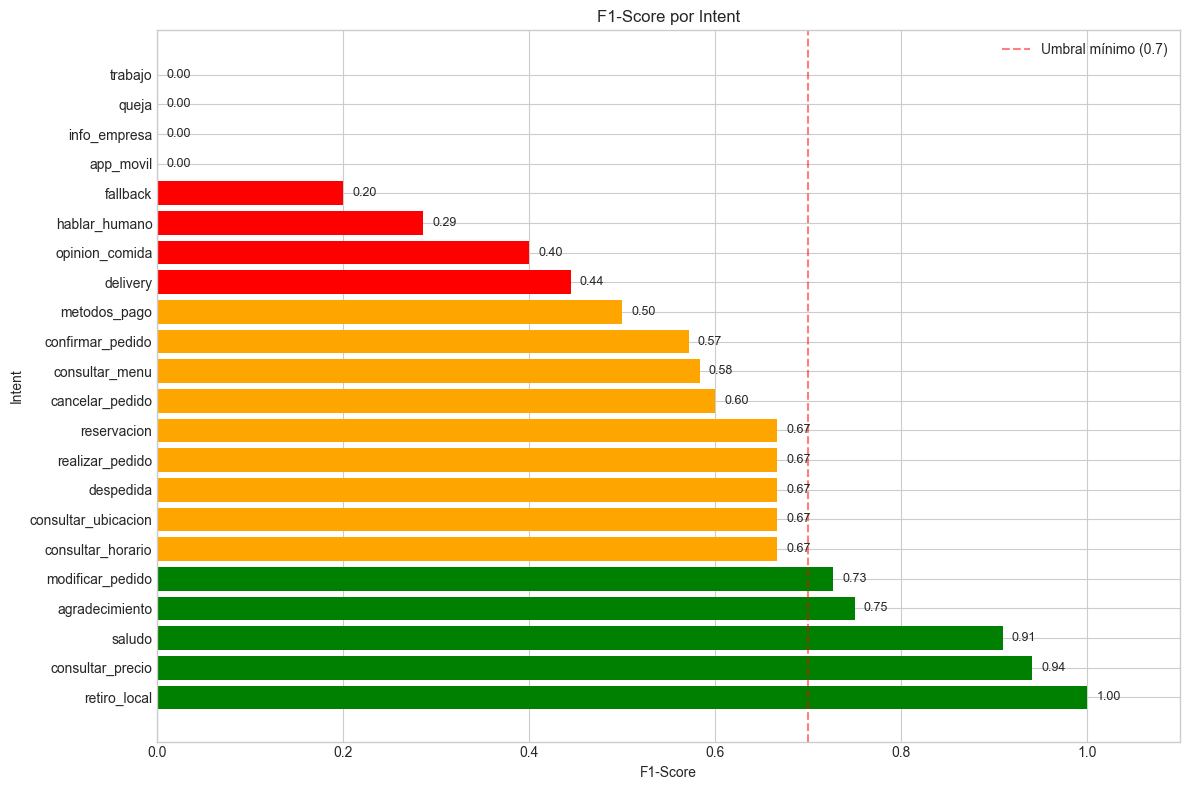


⚠️ Intents con F1 < 0.7 (necesitan más ejemplos):
   - consultar_horario: 0.67
   - consultar_ubicacion: 0.67
   - despedida: 0.67
   - realizar_pedido: 0.67
   - reservacion: 0.67
   - cancelar_pedido: 0.60
   - consultar_menu: 0.58
   - confirmar_pedido: 0.57
   - metodos_pago: 0.50
   - delivery: 0.44
   - opinion_comida: 0.40
   - hablar_humano: 0.29
   - fallback: 0.20
   - app_movil: 0.00
   - info_empresa: 0.00
   - queja: 0.00
   - trabajo: 0.00


In [7]:
# Calcular F1 por clase
from sklearn.metrics import f1_score as f1_per_class

# Obtener etiquetas únicas ordenadas
unique_labels = sorted(set(y_true + y_pred))

# Calcular F1 para cada clase
f1_per_intent = {}
for label in unique_labels:
    y_true_binary = [1 if y == label else 0 for y in y_true]
    y_pred_binary = [1 if y == label else 0 for y in y_pred]
    f1_per_intent[label] = f1_score(y_true_binary, y_pred_binary, zero_division=0)

# Ordenar por F1 score
f1_sorted = dict(sorted(f1_per_intent.items(), key=lambda x: x[1], reverse=True))

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if v >= 0.7 else 'orange' if v >= 0.5 else 'red' for v in f1_sorted.values()]
bars = ax.barh(list(f1_sorted.keys()), list(f1_sorted.values()), color=colors)

# Agregar línea de umbral
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Umbral mínimo (0.7)')

# Agregar valores
for bar, val in zip(bars, f1_sorted.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('F1-Score')
ax.set_ylabel('Intent')
ax.set_title('F1-Score por Intent')
ax.set_xlim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

# Identificar intents problemáticos
intents_bajos = {k: v for k, v in f1_sorted.items() if v < 0.7}
if intents_bajos:
    print(f"\n⚠️ Intents con F1 < 0.7 (necesitan más ejemplos):")
    for intent, score in intents_bajos.items():
        print(f"   - {intent}: {score:.2f}")

## 8. Matriz de Confusión

La matriz de confusión muestra qué intents se confunden entre sí:
- **Diagonal**: Predicciones correctas (queremos valores altos aquí)
- **Fuera de diagonal**: Confusiones (errores del modelo)

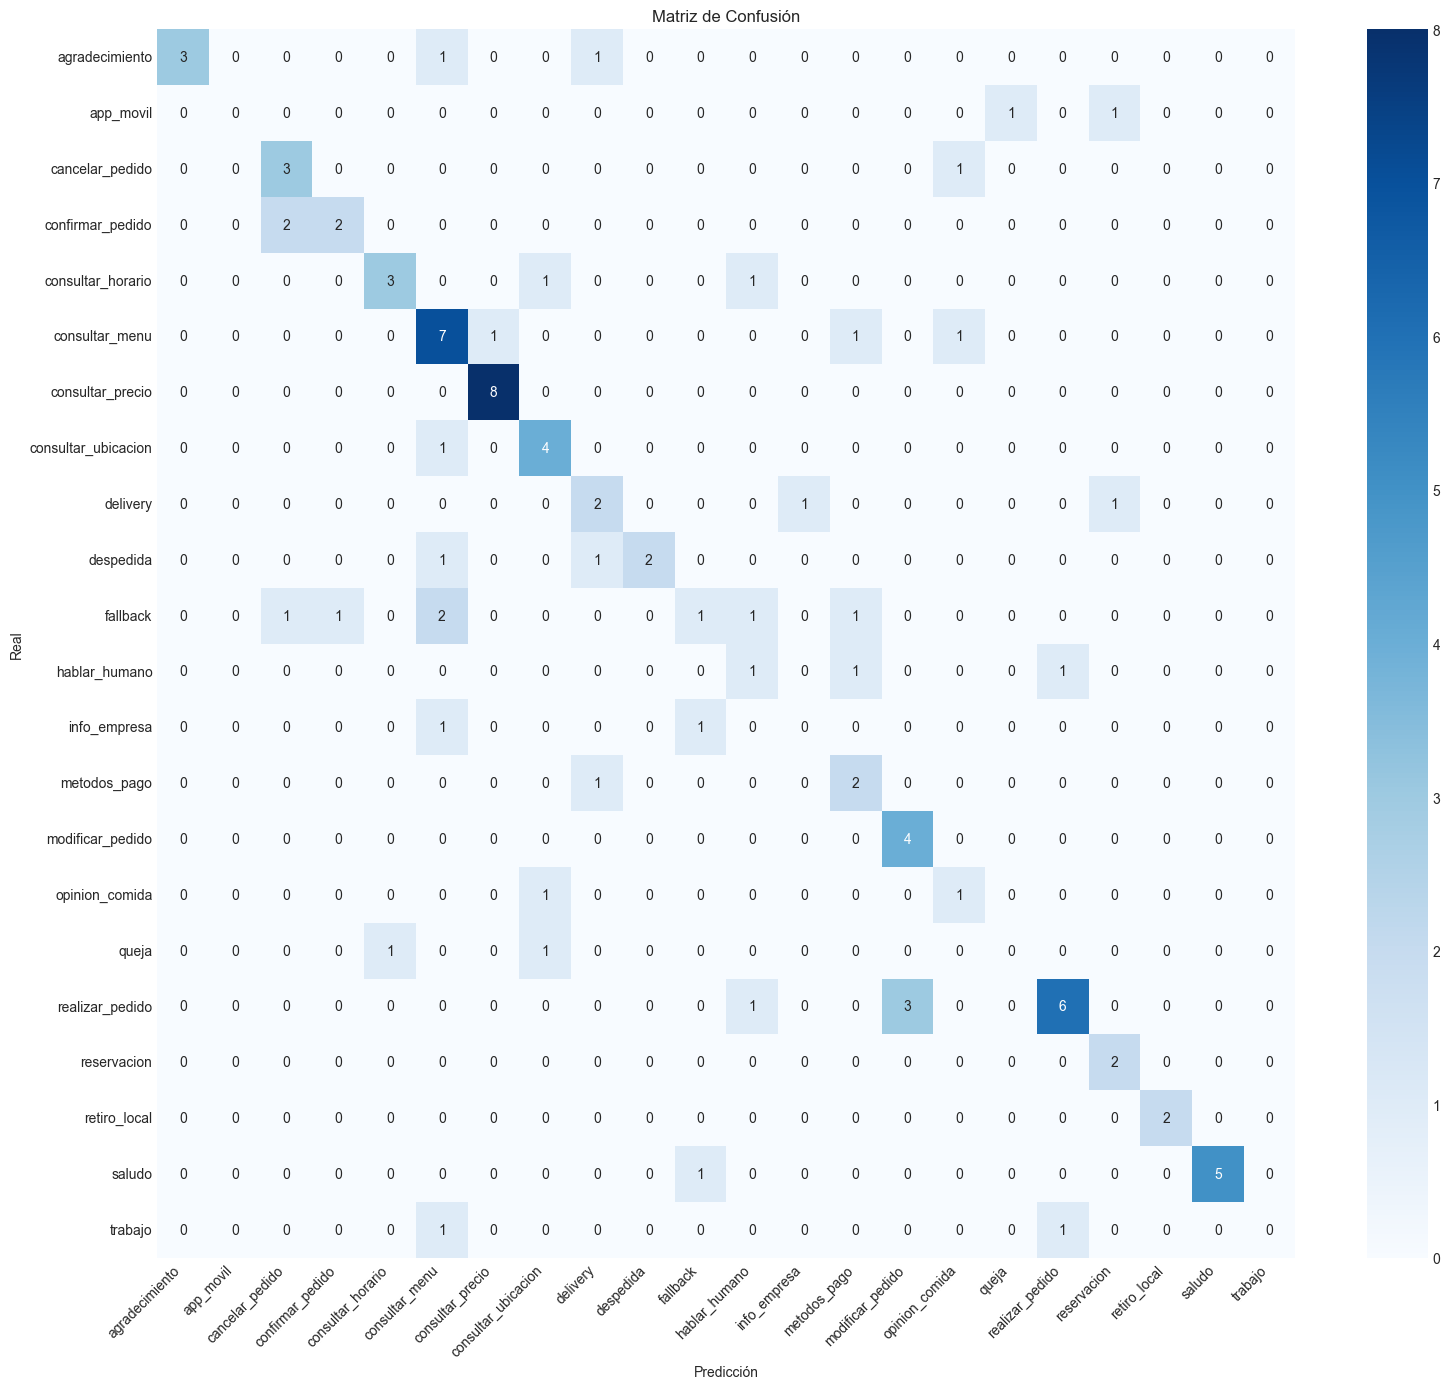

In [8]:
# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

# Crear heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, yticklabels=unique_labels, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Análisis de Confusiones Frecuentes

Identificamos los pares de intents que más se confunden entre sí.

In [9]:
# Encontrar confusiones (errores fuera de la diagonal)
confusions = []
for i, true_label in enumerate(unique_labels):
    for j, pred_label in enumerate(unique_labels):
        if i != j and cm[i, j] > 0:  # Fuera de diagonal y con errores
            confusions.append({
                'real': true_label,
                'predicho': pred_label,
                'errores': cm[i, j]
            })

# Ordenar por número de errores
confusions_df = pd.DataFrame(confusions).sort_values('errores', ascending=False)

if len(confusions_df) > 0:
    print("❌ CONFUSIONES MÁS FRECUENTES")
    print("=" * 60)
    print("\nCuando el intent real es X, el modelo predice Y:\n")
    for _, row in confusions_df.head(10).iterrows():
        print(f"   {row['real']} → {row['predicho']}: {row['errores']} error(es)")
else:
    print("✅ ¡No hay confusiones! El modelo clasifica perfectamente.")

❌ CONFUSIONES MÁS FRECUENTES

Cuando el intent real es X, el modelo predice Y:

   realizar_pedido → modificar_pedido: 3 error(es)
   confirmar_pedido → cancelar_pedido: 2 error(es)
   fallback → consultar_menu: 2 error(es)
   agradecimiento → consultar_menu: 1 error(es)
   agradecimiento → delivery: 1 error(es)
   app_movil → queja: 1 error(es)
   consultar_horario → consultar_ubicacion: 1 error(es)
   consultar_horario → hablar_humano: 1 error(es)
   app_movil → reservacion: 1 error(es)
   cancelar_pedido → opinion_comida: 1 error(es)


## 10. Distribución de Confianza del Modelo

Analizamos qué tan "seguro" está el modelo de sus predicciones.
- **Alta confianza** (>0.8): El modelo está muy seguro
- **Baja confianza** (<0.5): El modelo tiene dudas

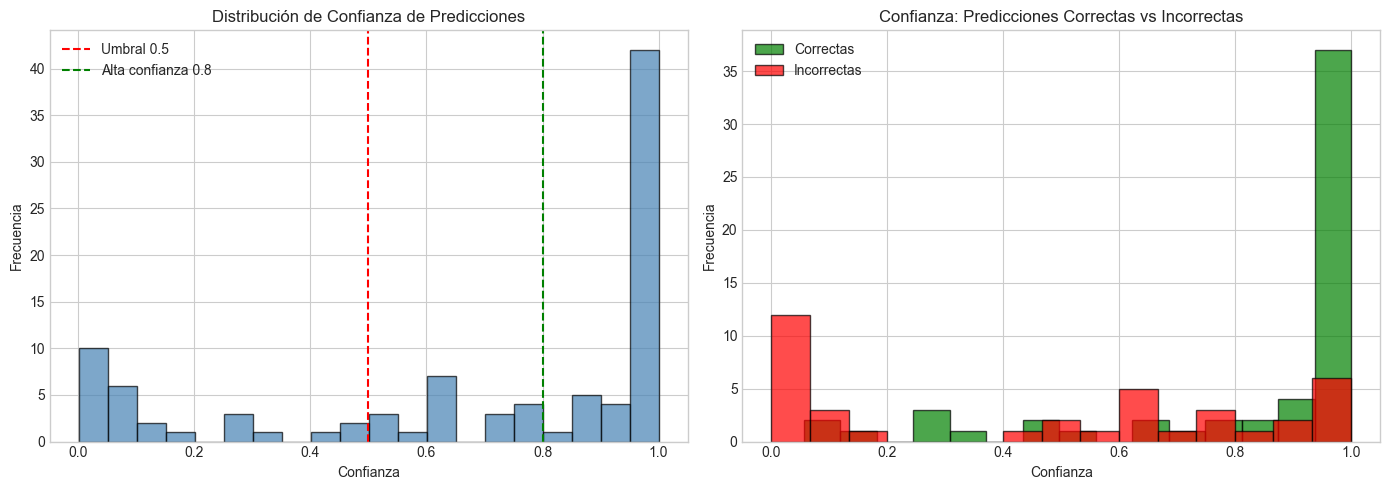

📊 ESTADÍSTICAS DE CONFIANZA
   Confianza promedio: 68.59%
   Confianza mínima: 0.12%
   Confianza máxima: 99.99%
   Predicciones con confianza < 50%: 26
   Predicciones con confianza > 80%: 52


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma general de confianza
axes[0].hist(y_conf, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
axes[0].axvline(x=0.8, color='green', linestyle='--', label='Alta confianza 0.8')
axes[0].set_xlabel('Confianza')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Confianza de Predicciones')
axes[0].legend()

# Confianza correctos vs incorrectos
correct_mask = [t == p for t, p in zip(y_true, y_pred)]
conf_correct = [c for c, m in zip(y_conf, correct_mask) if m]
conf_incorrect = [c for c, m in zip(y_conf, correct_mask) if not m]

axes[1].hist(conf_correct, bins=15, alpha=0.7, label='Correctas', color='green', edgecolor='black')
axes[1].hist(conf_incorrect, bins=15, alpha=0.7, label='Incorrectas', color='red', edgecolor='black')
axes[1].set_xlabel('Confianza')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Confianza: Predicciones Correctas vs Incorrectas')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticas de confianza
print(f"📊 ESTADÍSTICAS DE CONFIANZA")
print(f"   Confianza promedio: {np.mean(y_conf):.2%}")
print(f"   Confianza mínima: {np.min(y_conf):.2%}")
print(f"   Confianza máxima: {np.max(y_conf):.2%}")
print(f"   Predicciones con confianza < 50%: {sum(1 for c in y_conf if c < 0.5)}")
print(f"   Predicciones con confianza > 80%: {sum(1 for c in y_conf if c > 0.8)}")

## 11. Análisis de Predicciones Incorrectas

Revisamos ejemplos específicos donde el modelo se equivocó para entender sus debilidades.

In [13]:
# Crear DataFrame con predicciones incorrectas
errors = []
for i, (text, true, pred, conf) in enumerate(zip(val_texts, y_true, y_pred, y_conf)):
    if true != pred:
        errors.append({
            'texto': text[:80] + '...' if len(text) > 80 else text,
            'real': true,
            'predicho': pred,
            'confianza': f"{conf:.1%}"
        })

errors_df = pd.DataFrame(errors)

if len(errors_df) > 0:
    print(f"❌ PREDICCIONES INCORRECTAS ({len(errors_df)} errores)")
    print("=" * 100)
    display(errors_df)
else:
    print("✅ ¡No hay errores! El modelo clasifica correctamente todos los ejemplos de prueba.")

❌ PREDICCIONES INCORRECTAS (38 errores)


,texto,real,predicho,confianza
0,horarios de atencion,consultar_horario,hablar_humano,61.7%
1,deme una humita,realizar_pedido,hablar_humano,2.3%
2,quiero agregar chorizo,realizar_pedido,modificar_pedido,99.5%
3,pago contra entrega,metodos_pago,delivery,76.5%
4,quiero trabajar con ustedes,trabajo,realizar_pedido,51.0%
5,tienen app,app_movil,reservacion,0.1%
6,ya no lo quiero,cancelar_pedido,opinion_comida,77.0%
7,tienen repartidor,delivery,reservacion,97.8%
8,horario portal shopping,consultar_horario,consultar_ubicacion,56.8%
9,quisiera ordenar comida,realizar_pedido,modificar_pedido,5.6%


## 12. Resumen Final y Recomendaciones

Basándonos en todas las métricas evaluadas, hacemos un diagnóstico del modelo.

In [14]:
# Diagnóstico automático basado en métricas
print("=" * 70)
print("📋 RESUMEN FINAL DEL MODELO")
print("=" * 70)

# Evaluar rendimiento general
if accuracy >= 0.9:
    print(f"\n✅ EXCELENTE: Accuracy de {accuracy:.1%}")
    print("   El modelo está listo para producción.")
elif accuracy >= 0.8:
    print(f"\n🟡 BUENO: Accuracy de {accuracy:.1%}")
    print("   El modelo es aceptable para producción con monitoreo.")
elif accuracy >= 0.7:
    print(f"\n🟠 REGULAR: Accuracy de {accuracy:.1%}")
    print("   Considera agregar más ejemplos de entrenamiento.")
else:
    print(f"\n🔴 BAJO: Accuracy de {accuracy:.1%}")
    print("   Se requiere mejorar significativamente el modelo.")

# Identificar intents problemáticos
print(f"\n📊 RESUMEN DE MÉTRICAS:")
print(f"   • Accuracy: {accuracy:.1%}")
print(f"   • Precision (macro): {precision:.1%}")
print(f"   • Recall (macro): {recall:.1%}")
print(f"   • F1-Score (macro): {f1:.1%}")

# Intents con bajo rendimiento (usando f1_per_intent calculado anteriormente)
low_f1_intents = {k: v for k, v in f1_per_intent.items() if v < 0.7}
if len(low_f1_intents) > 0:
    print(f"\n⚠️  INTENTS CON F1 < 70% (necesitan más ejemplos):")
    for intent, score in low_f1_intents.items():
        print(f"   • {intent}: {score:.1%}")
else:
    print(f"\n✅ Todos los intents tienen F1 ≥ 70%")

# Recomendaciones
print("\n💡 RECOMENDACIONES:")
recommendations = []
if accuracy < 0.85:
    recommendations.append("1. Agregar más ejemplos de entrenamiento")
if len(confusions_df) > 3:
    recommendations.append("2. Revisar intents muy similares que se confunden")
if np.mean(y_conf) < 0.7:
    recommendations.append("3. El modelo tiene baja confianza promedio, necesita más datos")

if recommendations:
    for r in recommendations:
        print(f"   {r}")
else:
    print("   ¡El modelo tiene buen rendimiento! Solo monitorear en producción.")

print("\n" + "=" * 70)
print("Modelo guardado en: ../models/intent_classifier/")
print("=" * 70)

📋 RESUMEN FINAL DEL MODELO

🔴 BAJO: Accuracy de 60.4%
   Se requiere mejorar significativamente el modelo.

📊 RESUMEN DE MÉTRICAS:
   • Accuracy: 60.4%
   • Precision (macro): 51.9%
   • Recall (macro): 54.7%
   • F1-Score (macro): 51.1%

⚠️  INTENTS CON F1 < 70% (necesitan más ejemplos):
   • app_movil: 0.0%
   • cancelar_pedido: 60.0%
   • confirmar_pedido: 57.1%
   • consultar_horario: 66.7%
   • consultar_menu: 58.3%
   • consultar_ubicacion: 66.7%
   • delivery: 44.4%
   • despedida: 66.7%
   • fallback: 20.0%
   • hablar_humano: 28.6%
   • info_empresa: 0.0%
   • metodos_pago: 50.0%
   • opinion_comida: 40.0%
   • queja: 0.0%
   • realizar_pedido: 66.7%
   • reservacion: 66.7%
   • trabajo: 0.0%

💡 RECOMENDACIONES:
   1. Agregar más ejemplos de entrenamiento
   2. Revisar intents muy similares que se confunden
   3. El modelo tiene baja confianza promedio, necesita más datos

Modelo guardado en: ../models/intent_classifier/
